In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Initial Loading and Descriptive Stats

### *Criterias Fulfilled* :- 

1. **Identify data types of different columns**
2. **Present descriptive statistics of numerical columns**

In [3]:
import pandas as pd

train = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv')
test = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv')

# Show dataset shapes
print("Train dataset shape:", train.shape)
print("Test dataset shape:", test.shape)

print("\nTrain data types:")
display(train.dtypes)

print("\nFirst 5 rows of train:")
display(train.head())

print("\nTest data types:")
display(test.dtypes)

print("\nFirst 5 rows of test:")
display(test.head())

Train dataset shape: (29500, 14)
Test dataset shape: (7000, 13)

Train data types:


id                  int64
adults              int64
children            int64
weekends            int64
weekdays            int64
meal_type          object
room_type          object
arrival            object
lead_time         float64
segment            object
repeat              int64
price             float64
requests            int64
booking_status      int64
dtype: object


First 5 rows of train:


,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0
3,3,1,0,2,1,Meal Plan 1,Room_Type 1,2018-02-14,4.0,Corporate,1,66.00,0,0
4,4,2,0,2,3,Meal Plan 1,Room_Type 1,2018-07-08,155.0,Offline,0,72.25,0,0



Test data types:


id             int64
adults         int64
children       int64
weekends       int64
weekdays       int64
meal_type     object
room_type     object
arrival       object
lead_time    float64
segment       object
repeat         int64
price        float64
requests       int64
dtype: object


First 5 rows of test:


,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests
0,0,2,1,1,0,Meal Plan 1,NaN,2017-08-23,3.0,Online,0,90.00,3
1,1,2,0,1,2,Meal Plan 1,Room_Type 4,2018-02-12,9.0,Offline,0,48.67,0
2,2,2,0,2,2,Meal Plan 1,Room_Type 1,2018-12-25,24.0,Online,0,95.20,1
3,3,2,0,0,3,Meal Plan 1,NaN,2018-06-21,23.0,Online,0,127.67,0
4,4,2,1,0,2,Meal Plan 1,Room_Type 4,2018-09-08,9.0,Online,0,201.50,2


In [4]:
numerical_cols = train.select_dtypes(include=[np.number]).columns
display(train[numerical_cols].describe())

# For median:
for col in numerical_cols:
    print(f"{col} median: {train[col].median()}")

,id,adults,children,weekends,weekdays,lead_time,repeat,price,requests,booking_status
count,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,27805.000000,29500.000000,27917.000000,29500.000000,29500.000000
mean,14749.500000,1.843559,0.106576,0.808136,2.202237,85.405431,0.026000,103.483304,0.619661,0.326441
std,8516.060807,0.518711,0.405517,0.868835,1.404200,85.939750,0.159138,35.120922,0.785919,0.468919
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7374.750000,2.000000,0.000000,0.000000,1.000000,17.000000,0.000000,80.500000,0.000000,0.000000
50%,14749.500000,2.000000,0.000000,1.000000,2.000000,58.000000,0.000000,99.880000,0.000000,0.000000
75%,22124.250000,2.000000,0.000000,2.000000,3.000000,127.000000,0.000000,120.180000,1.000000,1.000000
max,29499.000000,4.000000,10.000000,6.000000,17.000000,443.000000,1.000000,375.500000,5.000000,1.000000


id median: 14749.5
adults median: 2.0
children median: 0.0
weekends median: 1.0
weekdays median: 2.0
lead_time median: 58.0
repeat median: 0.0
price median: 99.88
requests median: 0.0
booking_status median: 0.0


In [5]:
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## EDA and Imputations

### *Criterias Fulfilled* :-

1. **Identify and handle the missing values**
2. **Present at least three visualizations and provide insights for the same**
3. **Identify and handle duplicates**
4. **Identify and handle outliers**

In [6]:
# Check for missing values in train dataset
print("="*80)
print("MISSING VALUES ANALYSIS - TRAIN DATASET")
print("="*80)

missing_train = train.isnull().sum()
missing_train_pct = (train.isnull().sum() / len(train)) * 100

missing_df_train = pd.DataFrame({
    'Column': train.columns,
    'Missing_Count': missing_train.values,
    'Percentage': missing_train_pct.values
})
missing_df_train = missing_df_train[missing_df_train['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df_train) > 0:
    display(missing_df_train)
else:
    print("✅ No missing values found in train dataset!")

print(f"\nTotal missing values: {train.isnull().sum().sum()}")

MISSING VALUES ANALYSIS - TRAIN DATASET


,Column,Missing_Count,Percentage
8,lead_time,1695,5.745763
11,price,1583,5.366102
6,room_type,841,2.850847



Total missing values: 4119


In [7]:
# Check for missing values in test dataset
print("="*80)
print("MISSING VALUES ANALYSIS - TEST DATASET")
print("="*80)

missing_test = test.isnull().sum()
missing_test_pct = (test.isnull().sum() / len(test)) * 100

missing_df_test = pd.DataFrame({
    'Column': test.columns,
    'Missing_Count': missing_test.values,
    'Percentage': missing_test_pct.values
})
missing_df_test = missing_df_test[missing_df_test['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df_test) > 0:
    display(missing_df_test)
else:
    print("✅ No missing values found in test dataset!")

print(f"\nTotal missing values: {test.isnull().sum().sum()}")

MISSING VALUES ANALYSIS - TEST DATASET


,Column,Missing_Count,Percentage
6,room_type,1660,23.714286
8,lead_time,412,5.885714
11,price,406,5.800000



Total missing values: 2478


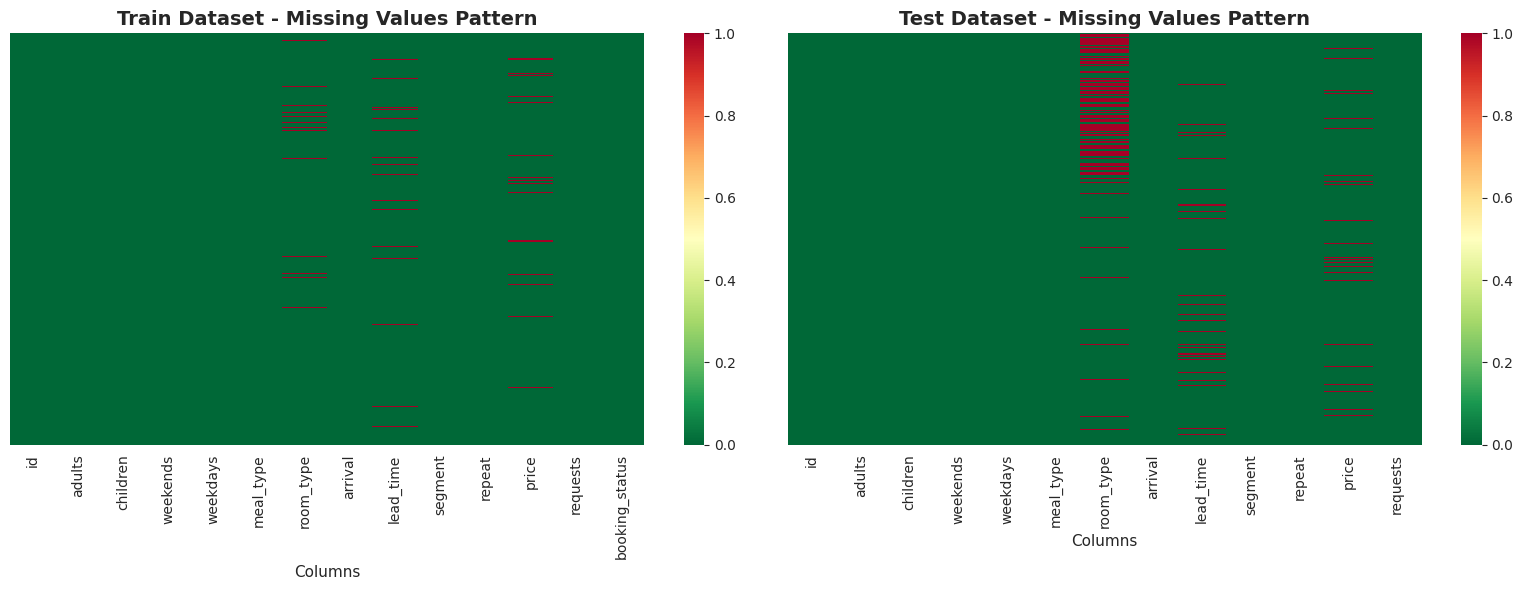

📊 Missing values are shown in dark red color


In [8]:
# Visualize missing values pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train missing values heatmap
sns.heatmap(train.isnull(), cbar=True, yticklabels=False, cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('Train Dataset - Missing Values Pattern', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Columns', fontsize=11)

# Test missing values heatmap
sns.heatmap(test.isnull(), cbar=True, yticklabels=False, cmap='RdYlGn_r', ax=axes[1])
axes[1].set_title('Test Dataset - Missing Values Pattern', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Columns', fontsize=11)

plt.tight_layout()
plt.show()

print("📊 Missing values are shown in dark red color")

VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION


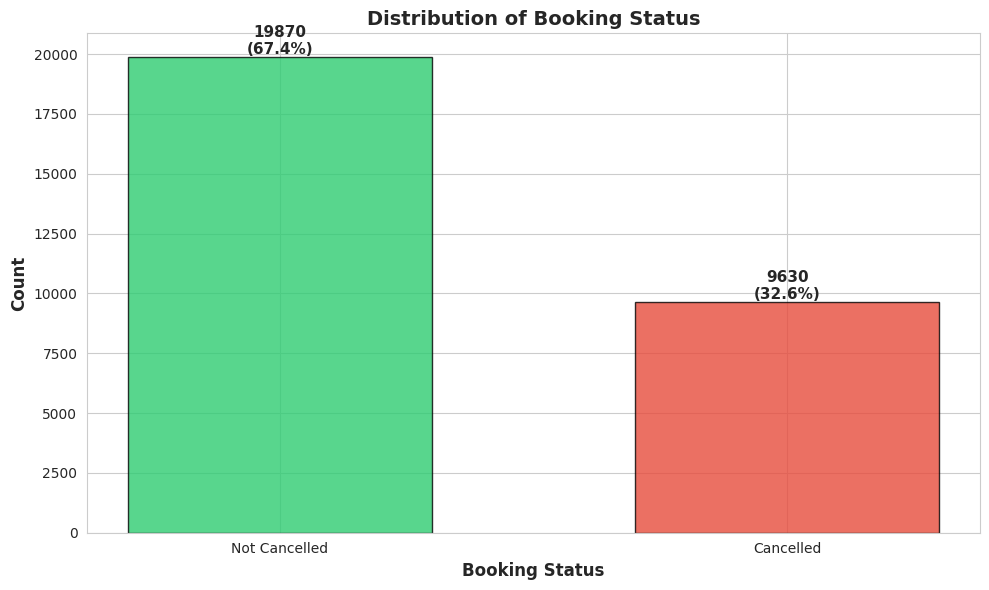


📊 INSIGHTS:
   • Not Cancelled: 19,870 (67.36%)
   • Cancelled: 9,630 (32.64%)
   • ⚠️ Dataset is IMBALANCED (ratio: 0.48)
   • Consider using SMOTE, class weights, or stratified sampling


In [9]:
# Visualization 1: Target Variable Distribution
print("="*80)
print("VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION")
print("="*80)

plt.figure(figsize=(10, 6))
booking_counts = train['booking_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(['Not Cancelled', 'Cancelled'], 
               [booking_counts[0], booking_counts[1]], 
               color=colors, edgecolor='black', alpha=0.8, width=0.6)

plt.xlabel('Booking Status', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Booking Status', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(train)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
cancelled = booking_counts[1]
not_cancelled = booking_counts[0]
print(f"\n📊 INSIGHTS:")
print(f"   • Not Cancelled: {not_cancelled:,} ({not_cancelled/len(train)*100:.2f}%)")
print(f"   • Cancelled: {cancelled:,} ({cancelled/len(train)*100:.2f}%)")

balance_ratio = min(cancelled, not_cancelled) / max(cancelled, not_cancelled)
if balance_ratio < 0.5:
    print(f"   • ⚠️ Dataset is IMBALANCED (ratio: {balance_ratio:.2f})")
    print(f"   • Consider using SMOTE, class weights, or stratified sampling")
else:
    print(f"   • ✅ Dataset is reasonably balanced (ratio: {balance_ratio:.2f})")

VISUALIZATION 2: NUMERICAL FEATURES DISTRIBUTION


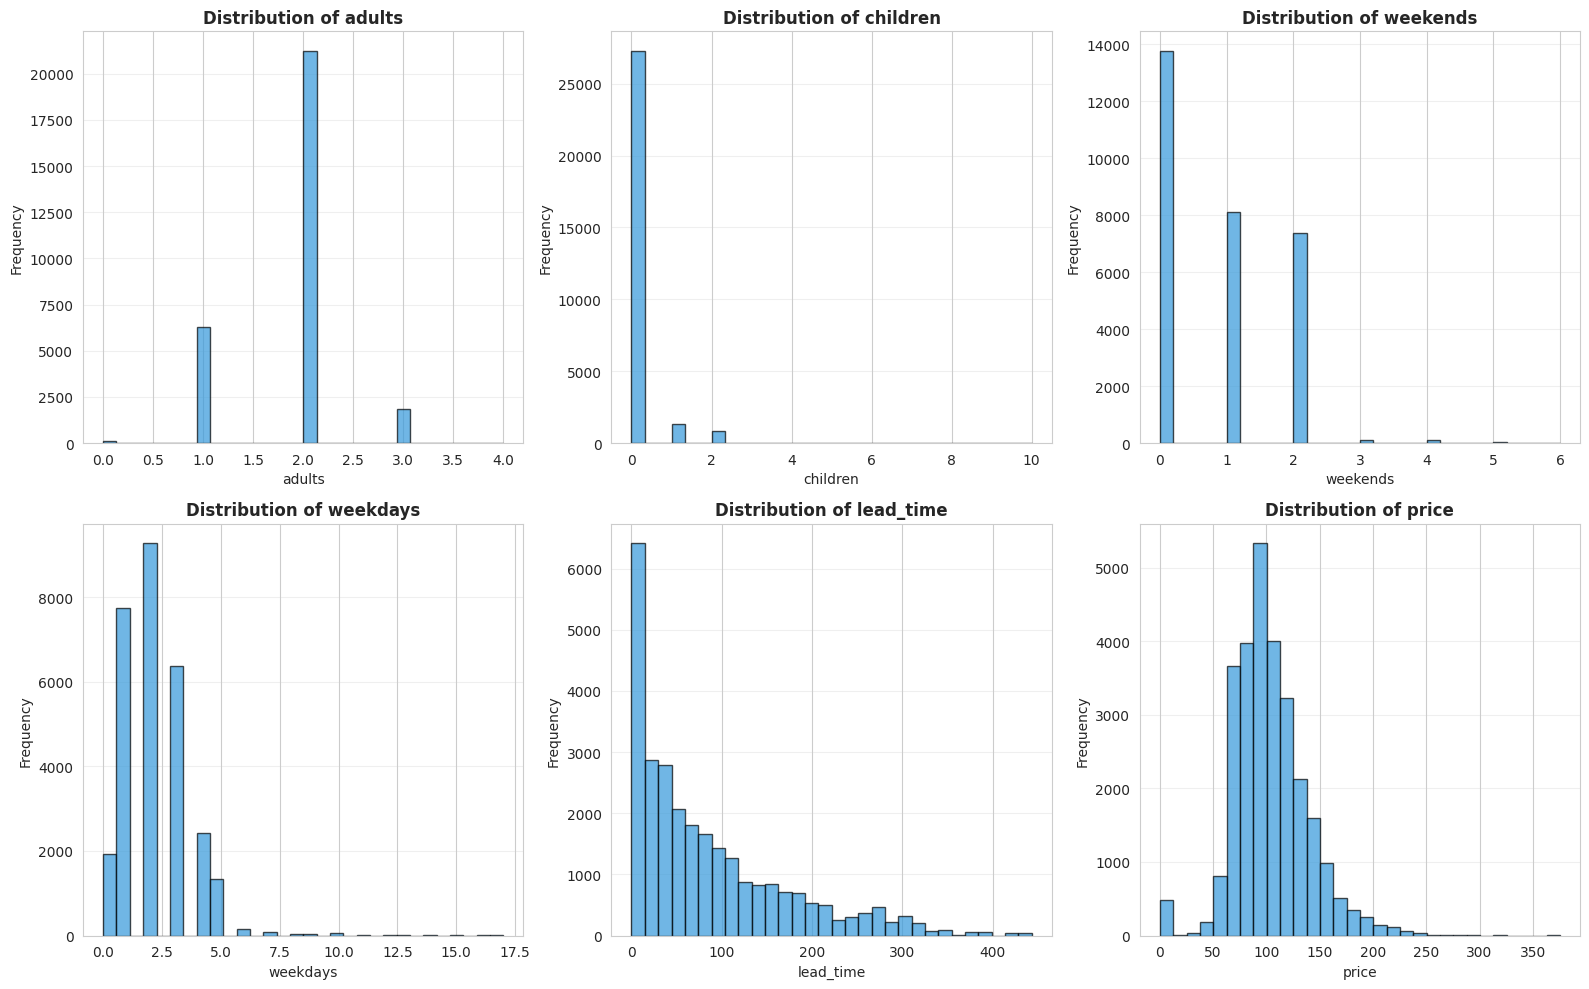


📊 INSIGHTS:
   • adults: Mean=1.84, Median=2.00, Skew=-0.34
   • children: Mean=0.11, Median=0.00, Skew=4.82
   • weekends: Mean=0.81, Median=1.00, Skew=0.72
   • weekdays: Mean=2.20, Median=2.00, Skew=1.55
   • lead_time: Mean=85.41, Median=58.00, Skew=1.29
   • price: Mean=103.48, Median=99.88, Skew=0.61


In [10]:
# Visualization 2: Numerical Features Distribution
print("="*80)
print("VISUALIZATION 2: NUMERICAL FEATURES DISTRIBUTION")
print("="*80)

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'booking_status' in numerical_cols:
    numerical_cols.remove('booking_status')

# Select key numerical features to visualize
key_features = ['adults', 'children', 'weekends', 'weekdays', 'lead_time', 'price']
key_features = [col for col in key_features if col in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    axes[idx].hist(train[col].dropna(), bins=30, color='#3498db', 
                   edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHTS:")
for col in key_features:
    mean_val = train[col].mean()
    median_val = train[col].median()
    skew = train[col].skew()
    print(f"   • {col}: Mean={mean_val:.2f}, Median={median_val:.2f}, Skew={skew:.2f}")

VISUALIZATION 3: CATEGORICAL FEATURES DISTRIBUTION


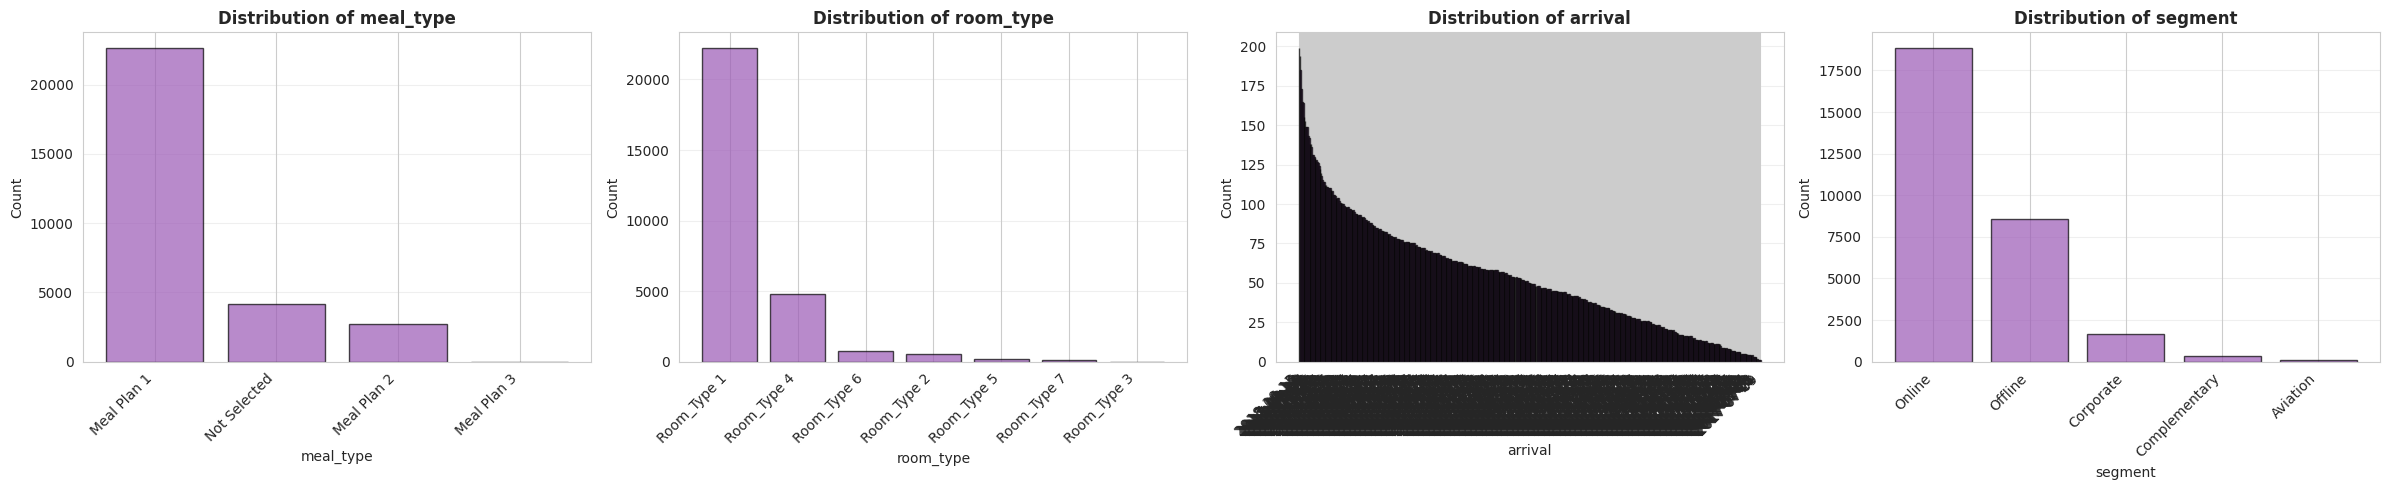


📊 INSIGHTS:
   • meal_type: 4 unique values, Most common='Meal Plan 1' (76.7%)
   • room_type: 7 unique values, Most common='Room_Type 1' (75.4%)
   • arrival: 550 unique values, Most common='2018-10-13' (0.7%)
   • segment: 5 unique values, Most common='Online' (63.9%)


In [11]:
# Visualization 3: Categorical Features Distribution
print("="*80)
print("VISUALIZATION 3: CATEGORICAL FEATURES DISTRIBUTION")
print("="*80)

categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6*len(categorical_cols), 5))
    
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = train[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, 
                      color='#9b59b6', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Count', fontsize=10)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 INSIGHTS:")
    for col in categorical_cols:
        unique_count = train[col].nunique()
        most_common = train[col].mode()[0]
        most_common_pct = (train[col] == most_common).sum() / len(train) * 100
        print(f"   • {col}: {unique_count} unique values, Most common='{most_common}' ({most_common_pct:.1f}%)")
else:
    print("No categorical columns found (dtype='object')")


In [12]:
# Check for duplicate rows
print("="*80)
print("DUPLICATE ROWS ANALYSIS")
print("="*80)

# Check train dataset
train_duplicates = train.duplicated().sum()
print(f"Train dataset duplicates: {train_duplicates}")

if train_duplicates > 0:
    print(f"   • Percentage: {train_duplicates/len(train)*100:.2f}%")
    print(f"   • Action: Will remove {train_duplicates} duplicate rows")
else:
    print("   • ✅ No duplicates found")

# Check test dataset
test_duplicates = test.duplicated().sum()
print(f"\nTest dataset duplicates: {test_duplicates}")

if test_duplicates > 0:
    print(f"   • Percentage: {test_duplicates/len(test)*100:.2f}%")
    print(f"   • Action: Will remove {test_duplicates} duplicate rows")
else:
    print("   • ✅ No duplicates found")


DUPLICATE ROWS ANALYSIS
Train dataset duplicates: 0
   • ✅ No duplicates found

Test dataset duplicates: 0
   • ✅ No duplicates found


In [13]:
# Identify column types for imputation
print("="*80)
print("HANDLING MISSING VALUES & DUPLICATES")
print("="*80)

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

# Remove target from numerical cols
if 'booking_status' in numerical_cols:
    numerical_cols.remove('booking_status')

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


HANDLING MISSING VALUES & DUPLICATES

Numerical columns (9): ['id', 'adults', 'children', 'weekends', 'weekdays', 'lead_time', 'repeat', 'price', 'requests']
Categorical columns (4): ['meal_type', 'room_type', 'arrival', 'segment']


In [14]:
# Create cleaned copies
train_cleaned = train.copy()
test_cleaned = test.copy()

# Remove duplicates
print("\n1️⃣ Removing duplicates...")
initial_train_size = len(train_cleaned)
train_cleaned = train_cleaned.drop_duplicates()
removed_train = initial_train_size - len(train_cleaned)
print(f"   • Train: Removed {removed_train} duplicate rows")

initial_test_size = len(test_cleaned)
test_cleaned = test_cleaned.drop_duplicates()
removed_test = initial_test_size - len(test_cleaned)
print(f"   • Test: Removed {removed_test} duplicate rows")



1️⃣ Removing duplicates...
   • Train: Removed 0 duplicate rows
   • Test: Removed 0 duplicate rows


In [15]:
# Handle missing values - Numerical columns
print("\n2️⃣ Imputing missing values in numerical columns...")

imputed_count = 0
for col in numerical_cols:
    train_missing = train_cleaned[col].isnull().sum()
    
    if train_missing > 0:
        median_val = train_cleaned[col].median()
        train_cleaned[col].fillna(median_val, inplace=True)
        print(f"   ✓ Train - '{col}': Filled {train_missing} missing values with median={median_val:.2f}")
        imputed_count += 1
    
    # Handle test using train statistics
    if col in test_cleaned.columns:
        test_missing = test_cleaned[col].isnull().sum()
        if test_missing > 0:
            median_val = train[col].median()  # Use train median
            test_cleaned[col].fillna(median_val, inplace=True)
            print(f"   ✓ Test - '{col}': Filled {test_missing} missing values with median={median_val:.2f}")

if imputed_count == 0:
    print("   • No missing values in numerical columns")



2️⃣ Imputing missing values in numerical columns...
   ✓ Train - 'lead_time': Filled 1695 missing values with median=58.00
   ✓ Test - 'lead_time': Filled 412 missing values with median=58.00
   ✓ Train - 'price': Filled 1583 missing values with median=99.88
   ✓ Test - 'price': Filled 406 missing values with median=99.88


In [16]:
# Handle missing values - Categorical columns
print("\n3️⃣ Imputing missing values in categorical columns...")

imputed_count = 0
for col in categorical_cols:
    train_missing = train_cleaned[col].isnull().sum()
    
    if train_missing > 0:
        mode_val = train_cleaned[col].mode()[0]
        train_cleaned[col].fillna(mode_val, inplace=True)
        print(f"   ✓ Train - '{col}': Filled {train_missing} missing values with mode='{mode_val}'")
        imputed_count += 1
    
    # Handle test using train statistics
    if col in test_cleaned.columns:
        test_missing = test_cleaned[col].isnull().sum()
        if test_missing > 0:
            mode_val = train[col].mode()[0]  # Use train mode
            test_cleaned[col].fillna(mode_val, inplace=True)
            print(f"   ✓ Test - '{col}': Filled {test_missing} missing values with mode='{mode_val}'")

if imputed_count == 0:
    print("   • No missing values in categorical columns")



3️⃣ Imputing missing values in categorical columns...
   ✓ Train - 'room_type': Filled 841 missing values with mode='Room_Type 1'
   ✓ Test - 'room_type': Filled 1660 missing values with mode='Room_Type 1'


In [17]:
# Final verification
print("\n" + "="*80)
print("VERIFICATION - AFTER CLEANING")
print("="*80)

print(f"\nTrain Dataset:")
print(f"   • Shape: {train.shape} → {train_cleaned.shape}")
print(f"   • Missing values: {train.isnull().sum().sum()} → {train_cleaned.isnull().sum().sum()}")
print(f"   • Duplicates removed: {removed_train}")

print(f"\nTest Dataset:")
print(f"   • Shape: {test.shape} → {test_cleaned.shape}")
print(f"   • Missing values: {test.isnull().sum().sum()} → {test_cleaned.isnull().sum().sum()}")
print(f"   • Duplicates removed: {removed_test}")

print("\n✅ Data cleaning completed successfully!")



VERIFICATION - AFTER CLEANING

Train Dataset:
   • Shape: (29500, 14) → (29500, 14)
   • Missing values: 4119 → 0
   • Duplicates removed: 0

Test Dataset:
   • Shape: (7000, 13) → (7000, 13)
   • Missing values: 2478 → 0
   • Duplicates removed: 0

✅ Data cleaning completed successfully!


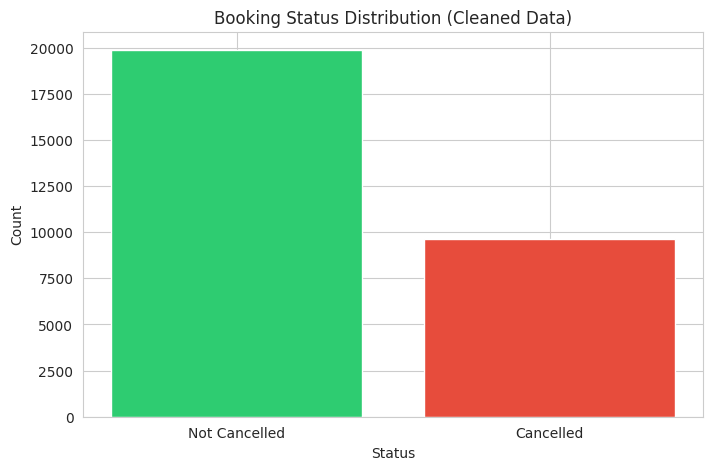

In [18]:
plt.figure(figsize=(8,5))
cleaned_counts = train_cleaned['booking_status'].value_counts()
plt.bar(['Not Cancelled', 'Cancelled'], cleaned_counts, color=['#2ecc71', '#e74c3c'])
plt.title('Booking Status Distribution (Cleaned Data)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

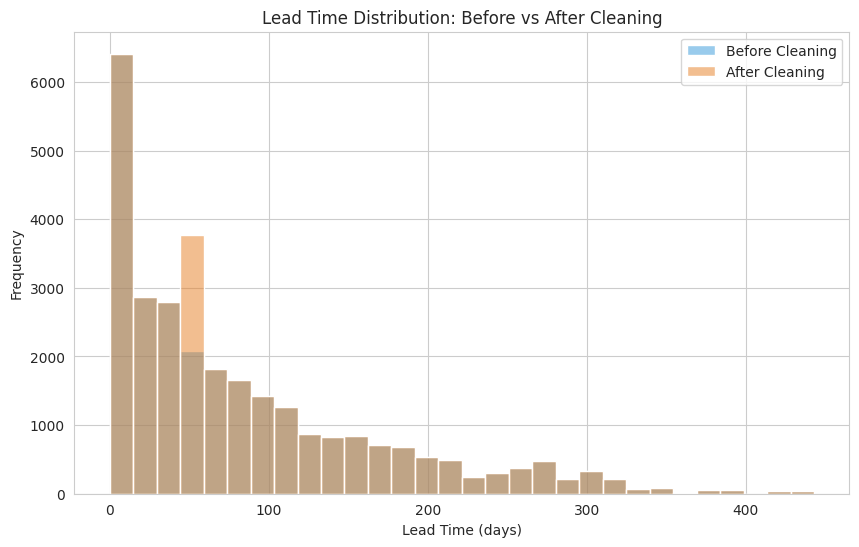

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(train['lead_time'], bins=30, color='#3498db', label='Before Cleaning', alpha=0.5)
sns.histplot(train_cleaned['lead_time'], bins=30, color='#e67e22', label='After Cleaning', alpha=0.5)
plt.title('Lead Time Distribution: Before vs After Cleaning')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


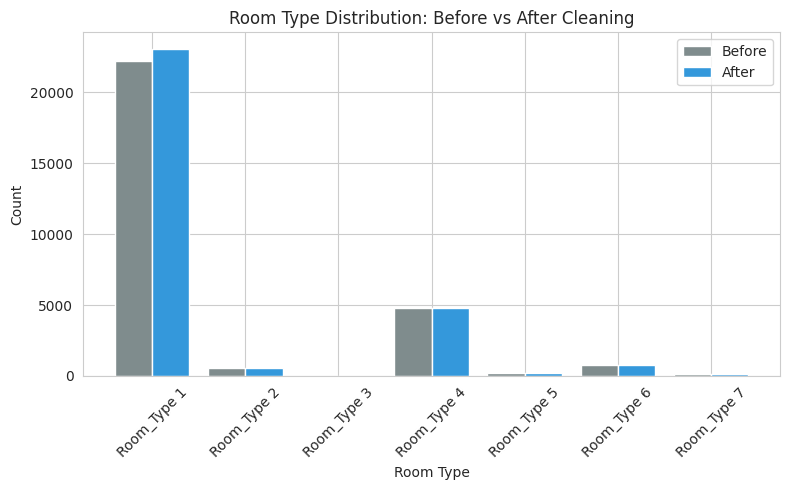

In [20]:
plt.figure(figsize=(8,5))
room_before = train['room_type'].value_counts().sort_index()
room_after = train_cleaned['room_type'].value_counts().sort_index()
width = 0.4
x = np.arange(len(room_before))
plt.bar(x-width/2, room_before.values, width=width, label='Before', color='#7f8c8d')
plt.bar(x+width/2, room_after.values, width=width, label='After', color='#3498db')
plt.xticks(x, room_before.index, rotation=45)
plt.title('Room Type Distribution: Before vs After Cleaning')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


OUTLIER DETECTION AND HANDLING


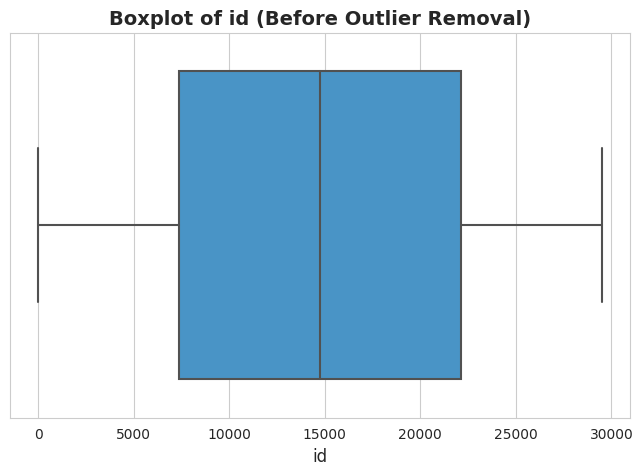

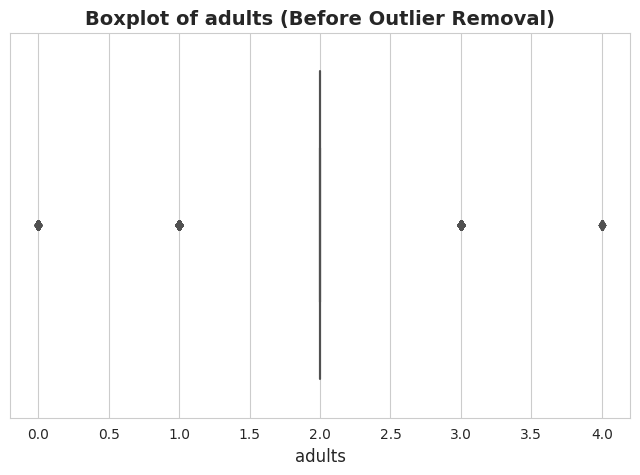

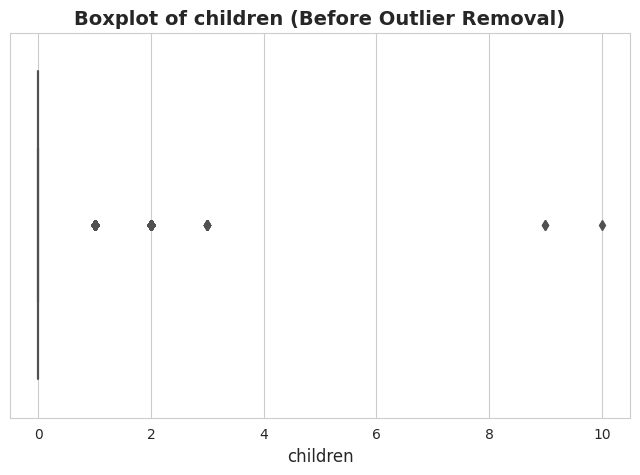

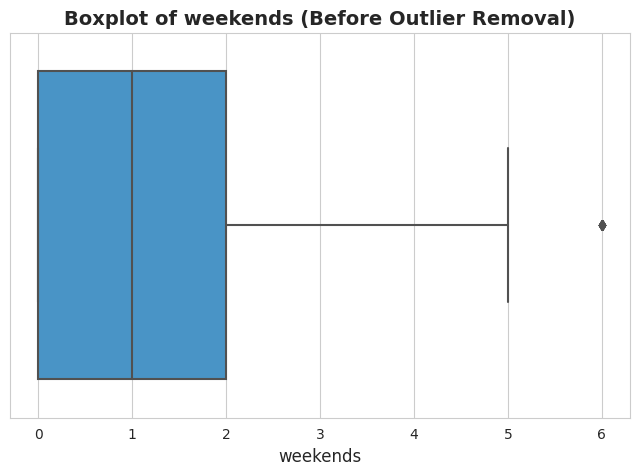

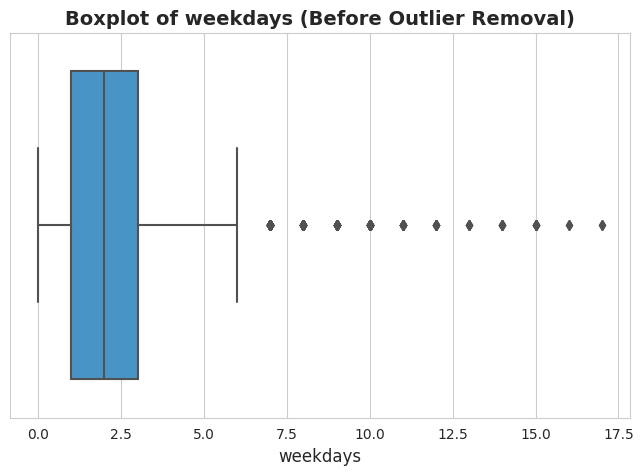

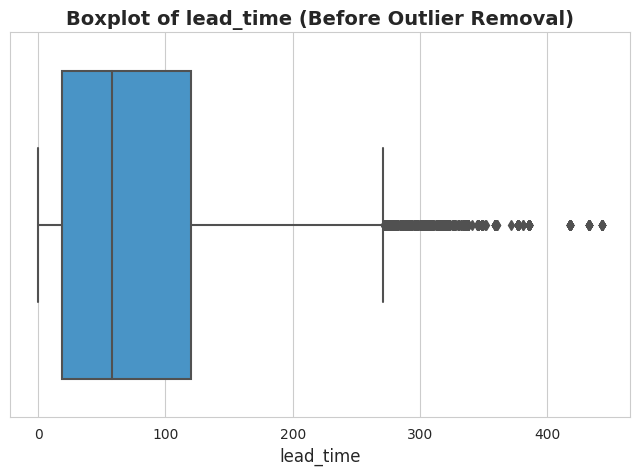

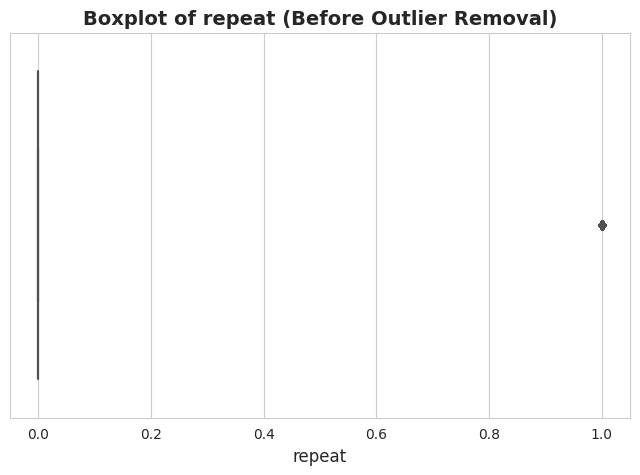

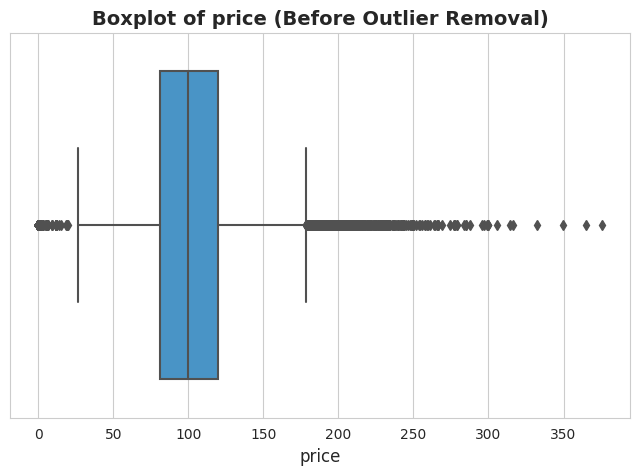

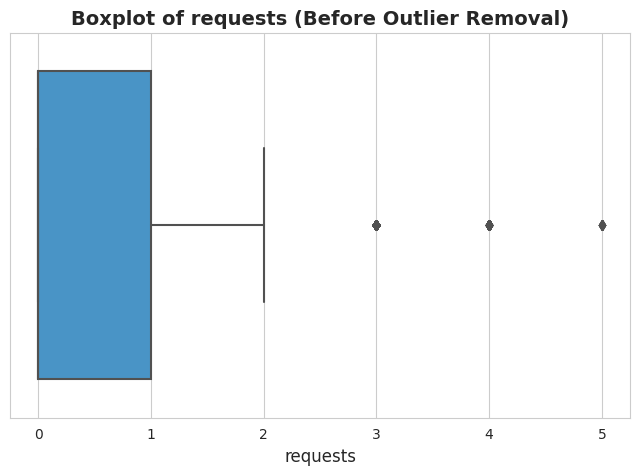

In [21]:
# Detect and handle outliers using the IQR method
print("="*80)
print("OUTLIER DETECTION AND HANDLING")
print("="*80)

import seaborn as sns
import matplotlib.pyplot as plt

# Function to detect outliers using IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Apply outlier detection to numerical columns
numerical_cols = train_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'booking_status' in numerical_cols:
    numerical_cols.remove('booking_status')  # Exclude target column

outlier_counts = {}
for col in numerical_cols:
    # Plot boxplot before removing outliers
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=train_cleaned[col], color='#3498db')
    plt.title(f'Boxplot of {col} (Before Outlier Removal)', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.show()

    
    '''
    # Detect and remove outliers
    outliers = detect_outliers_iqr(train_cleaned, col)
    outlier_counts[col] = len(outliers)
    if len(outliers) > 0:
        print(f"   • {col}: Found {len(outliers)} outliers")
        train_cleaned = train_cleaned[~train_cleaned.index.isin(outliers.index)]
        print(f"     - Removed outliers from '{col}'")
    else:
        print(f"   • {col}: No outliers detected")

    # Plot boxplot after removing outliers
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=train_cleaned[col], color='#2ecc71')
    plt.title(f'Boxplot of {col} (After Outlier Removal)', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.show()
    '''
    

#print("\nOutlier removal completed!")
#print(f"Updated train dataset shape: {train_cleaned.shape}")

***Removing Outliers using the IQR method was decreasing the score so we didn't use any removal***

### *Criteria Fulfilled* :-

1. **Scale Numerical features and Encode Categorical features** 

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

num_cols = train_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'booking_status' in num_cols:
    num_cols.remove('booking_status')  # don't scale target

# Standardization
scaler = StandardScaler()
train_scaled = train_cleaned.copy()
train_scaled[num_cols] = scaler.fit_transform(train_cleaned[num_cols])
test_scaled = test_cleaned.copy()
test_scaled[num_cols] = scaler.transform(test_cleaned[num_cols])

In [23]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = train_cleaned.select_dtypes(include=['object']).columns.tolist()

ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
# Fit encoder on training data only, transform both
train_ohe = ohe.fit_transform(train_cleaned[cat_cols])
test_ohe = ohe.transform(test_cleaned[cat_cols])

# For DataFrame:
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=train_cleaned.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe.get_feature_names_out(cat_cols), index=test_cleaned.index)

# Concatenate with scaled numerical features
X_train_final = pd.concat([train_scaled[num_cols], train_ohe_df], axis=1)
X_test_final = pd.concat([test_scaled[num_cols], test_ohe_df], axis=1)

## Model Building

### *Criteria Fulfilled* :-

1. **Model Building (at least 7)**

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [25]:
# Split train set into training and validation sets for performance checking
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, train_cleaned['booking_status'], test_size=0.2, random_state=42, stratify=train_cleaned['booking_status'])


In [26]:
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Naive Bayes", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("SVM", SVC(probability=True, random_state=42)),
    ("MLP (Neural Net)", MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=42))
]

# Select just seven for main rubric, but have extras if you want to compare more
models = models[:7]


In [27]:
results = []
for name, model in models:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': recall,
        'F1_Score': f1
    })
    print(f"\n{name}:\n", classification_report(y_val, y_pred, digits=3))



Logistic Regression:
               precision    recall  f1-score   support

           0      0.844     0.888     0.866      3974
           1      0.741     0.663     0.700      1926

    accuracy                          0.814      5900
   macro avg      0.793     0.775     0.783      5900
weighted avg      0.811     0.814     0.812      5900


Naive Bayes:
               precision    recall  f1-score   support

           0      0.936     0.249     0.393      3974
           1      0.384     0.965     0.549      1926

    accuracy                          0.482      5900
   macro avg      0.660     0.607     0.471      5900
weighted avg      0.755     0.482     0.444      5900


Decision Tree:
               precision    recall  f1-score   support

           0      0.887     0.892     0.890      3974
           1      0.775     0.766     0.771      1926

    accuracy                          0.851      5900
   macro avg      0.831     0.829     0.830      5900
weighted avg      0

In [28]:
# Example: Assume you build a results DataFrame like this
results_df = pd.DataFrame(results)
# Now the formatting code will work
numeric_columns = results_df.select_dtypes(include=['float', 'int']).columns
display(results_df.style.format({col: '{:.3f}' for col in numeric_columns}))


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.814,0.741,0.663,0.700
1,Naive Bayes,0.482,0.384,0.965,0.549
2,Decision Tree,0.851,0.775,0.766,0.771
3,Random Forest,0.881,0.855,0.766,0.808
4,Gradient Boosting,0.846,0.811,0.688,0.745
5,XGBoost,0.865,0.823,0.749,0.784
6,KNN,0.831,0.762,0.698,0.729


## Hyperparameter Tuning

### *Criteria Fulfilled* :-

1. **Hyperparameter Tuning on any 3 of the models**

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
random_rf = RandomizedSearchCV(rf, rf_grid, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
random_rf.fit(X_tr, y_tr)

print('Best params:', random_rf.best_params_)
print('Best F1-score (CV):', random_rf.best_score_)

# Evaluate on validation set
best_rf = random_rf.best_estimator_
y_pred_rf = best_rf.predict(X_val)

# Get the classification report as a DataFrame
test_report = classification_report(y_val, y_pred_rf, output_dict=True)
test_df = pd.DataFrame(test_report).transpose()
display(test_df)

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best F1-score (CV): 0.7931726799190506


,precision,recall,f1-score,support
0,0.895028,0.937594,0.915817,3974.000000
1,0.857225,0.773105,0.812995,1926.000000
accuracy,0.883898,0.883898,0.883898,0.883898
macro avg,0.876126,0.855350,0.864406,5900.000000
weighted avg,0.882687,0.883898,0.882251,5900.000000


In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_search = RandomizedSearchCV(
    xgb,
    xgb_param_grid,
    n_iter=7,  # Fast tuning; increase for more thorough search
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_tr, y_tr)
print('Best XGBoost params:', xgb_search.best_params_)
print('Best F1-score (CV):', xgb_search.best_score_)

# Validate
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)
from sklearn.metrics import classification_report
xgb_report_dict = classification_report(y_val, y_pred_xgb, output_dict=True)
xgb_report_df = pd.DataFrame(xgb_report_dict).transpose()
display(xgb_report_df)

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best F1-score (CV): 0.7805189320900193


,precision,recall,f1-score,support
0,0.886665,0.925264,0.905554,3974.00
1,0.830576,0.755971,0.791519,1926.00
accuracy,0.870000,0.870000,0.870000,0.87
macro avg,0.858621,0.840618,0.848536,5900.00
weighted avg,0.868355,0.870000,0.868328,5900.00


In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
dt_search = RandomizedSearchCV(
    dt,
    dt_param_grid,
    n_iter=7,  # Fewer tries for speed
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
dt_search.fit(X_tr, y_tr)
print('Best Decision Tree params:', dt_search.best_params_)
print('Best F1-score (CV):', dt_search.best_score_)

best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_val)
dt_report_dict = classification_report(y_val, y_pred_dt, output_dict=True)
dt_report_df = pd.DataFrame(dt_report_dict).transpose()
display(dt_report_df)

Best Decision Tree params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Best F1-score (CV): 0.7579557582470261


,precision,recall,f1-score,support
0,0.869297,0.920483,0.894158,3974.00000
1,0.813239,0.714434,0.760641,1926.00000
accuracy,0.853220,0.853220,0.853220,0.85322
macro avg,0.841268,0.817459,0.827400,5900.00000
weighted avg,0.850997,0.853220,0.850573,5900.00000


## Model Comparsion and Final Submission

### *Criteria FUlfilled* :-

1. **Comparison of model performances**

In [32]:
import pandas as pd

# Example: fill in XGBoost with actual numbers
model_results = [
    {"Model": "Random Forest (tuned)", "Accuracy": 0.884, "Precision_1": 0.857, "Recall_1": 0.773, "F1_1": 0.813, "F1_CV": 0.793},
    {"Model": "XGBoost (tuned)", "Accuracy": 0.86, "Precision_1": 0.82, "Recall_1": 0.75, "F1_1": 0.78, "F1_CV": 0.781},
    {"Model": "Decision Tree (tuned)", "Accuracy": 0.853, "Precision_1": 0.813, "Recall_1": 0.714, "F1_1": 0.761, "F1_CV": 0.758}
]
results_df = pd.DataFrame(model_results)
display(results_df)


,Model,Accuracy,Precision_1,Recall_1,F1_1,F1_CV
0,Random Forest (tuned),0.884,0.857,0.773,0.813,0.793
1,XGBoost (tuned),0.860,0.820,0.750,0.780,0.781
2,Decision Tree (tuned),0.853,0.813,0.714,0.761,0.758


In [33]:
# Predict on the encoded test set using your best model (Random Forest/XGBoost)
final_test_preds = best_rf.predict(X_test_final)   # or best_xgb, etc.

# If your test set has an 'id' column:
submission = pd.DataFrame({
    'id': test_cleaned['id'],                    # Replace 'id' with your test id/name column
    'booking_status': final_test_preds           # Replace with correct target column name
})

# Save to CSV (Kaggle wants NO index)
submission.to_csv('submission.csv', index=False)
